In [50]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


For preprocessing:

In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline


Models:


In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


Metrics:



In [119]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    average_precision_score,
    ConfusionMatrixDisplay
)


In [54]:
df = pd.read_csv(
    "../../data/processed/ai4i_cleaned.csv"
)
df.head()


,machine_type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,machine_failure,temperature_difference,power_proxy
0,M,298.1,308.6,1551,42.8,0,0,10.5,66382.8
1,L,298.2,308.7,1408,46.3,3,0,10.5,65190.4
2,L,298.1,308.5,1498,49.4,5,0,10.4,74001.2
3,L,298.2,308.6,1433,39.5,7,0,10.4,56603.5
4,L,298.2,308.7,1408,40.0,9,0,10.5,56320.0


In [55]:
df.shape


(10000, 9)

4.4 Separate features and target

In [56]:
target = "machine_failure"

X = df.drop(columns=[target])
y = df[target]

print(X.shape)
print(y.shape)


(10000, 8)
(10000,)


4.5 Train/test split
stratify=y

This keeps the failure/non-failure ratio approximately the same in both datasets.

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [58]:
print("Training:")
print(y_train.value_counts(normalize=True))

print("\nTesting:")
print(y_test.value_counts(normalize=True))


Training:
machine_failure
0    0.966125
1    0.033875
Name: proportion, dtype: float64

Testing:
machine_failure
0    0.966
1    0.034
Name: proportion, dtype: float64


4.6 Define numerical and categorical features

In [59]:
categorical_features = [
    "machine_type"
]

numeric_features = [
    "air_temperature",
    "process_temperature",
    "rotational_speed",
    "torque",
    "tool_wear",
    "temperature_difference",
    "power_proxy"
]


4.7 Build the preprocessing pipeline

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)


Model 1 — Logistic Regression

In [97]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)


In [98]:
logistic_pipeline.fit(
    X_train,
    y_train
)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['machine_type','air_temperature','process_temperature',...,'tool_wear', 'temperature_difference','power_proxy']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By 

In [99]:
lr_pred = logistic_pipeline.predict(
    X_test
)


In [100]:
lr_prob = logistic_pipeline.predict_proba(
    X_test
)[:, 1]


In [ ]:
def evaluate_model(
    model_name,
    y_true,
    y_pred,
    y_prob
):
    
    accuracy = accuracy_score(
        y_true,
        y_pred
    )
    
    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )
    
    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )
    
    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )
    
    roc_auc = roc_auc_score(
        y_true,
        y_prob
    )
    
    pr_auc = average_precision_score(
        y_true,
        y_prob
    )
    
    print(f"\n{'=' * 50}")
    print(model_name)
    print(f"{'=' * 50}")
    
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(f"PR-AUC   : {pr_auc:.4f}")


In [102]:
evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred,
    lr_prob
)



Logistic Regression
----------------------------------------
Accuracy : 0.9675
Precision: 0.5714
Recall   : 0.1765
F1 Score : 0.2697
ROC-AUC  : 0.9257


In [103]:
print(
    classification_report(
        y_test,
        lr_pred,
        target_names=[
            "No Failure",
            "Failure"
        ]
    )
)


              precision    recall  f1-score   support

  No Failure       0.97      1.00      0.98      1932
     Failure       0.57      0.18      0.27        68

    accuracy                           0.97      2000
   macro avg       0.77      0.59      0.63      2000
weighted avg       0.96      0.97      0.96      2000



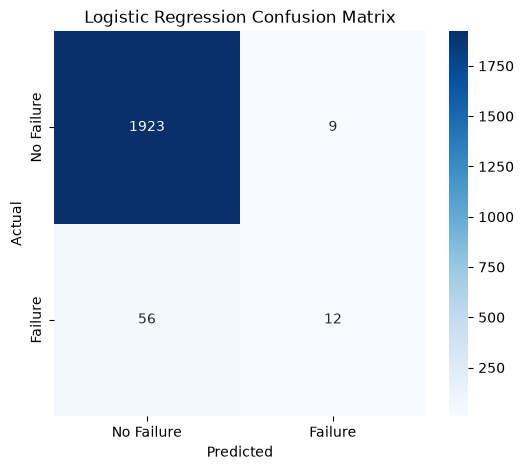

In [104]:
cm = confusion_matrix(
    y_test,
    lr_pred
)


plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Failure",
        "Failure"
    ],
    yticklabels=[
        "No Failure",
        "Failure"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()


Second model — Random Forest

In [105]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


In [106]:
random_forest_pipeline.fit(
    X_train,
    y_train
)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['machine_type','air_temperature','process_temperature',...,'tool_wear', 'temperature_difference','power_proxy']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By 

In [107]:
rf_pred = random_forest_pipeline.predict(
    X_test
)

rf_prob = random_forest_pipeline.predict_proba(
    X_test
)[:, 1]


In [108]:
evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)



Random Forest
----------------------------------------
Accuracy : 0.9910
Precision: 0.9464
Recall   : 0.7794
F1 Score : 0.8548
ROC-AUC  : 0.9642


In [109]:
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=[
            "No Failure",
            "Failure"
        ]
    )
)


              precision    recall  f1-score   support

  No Failure       0.99      1.00      1.00      1932
     Failure       0.95      0.78      0.85        68

    accuracy                           0.99      2000
   macro avg       0.97      0.89      0.93      2000
weighted avg       0.99      0.99      0.99      2000



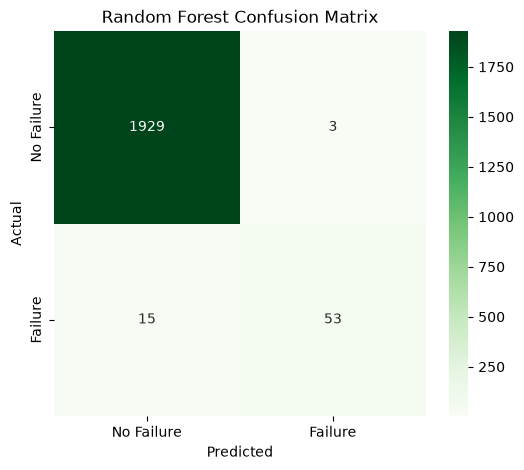

In [110]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=[
        "No Failure",
        "Failure"
    ],
    yticklabels=[
        "No Failure",
        "Failure"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()


In [79]:
! pip install xgboost



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [80]:
from xgboost import XGBClassifier


In [111]:
xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)


In [112]:
xgb_pipeline.fit(
    X_train,
    y_train
)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['machine_type','air_temperature','process_temperature',...,'tool_wear', 'temperature_difference','power_proxy']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By 

In [113]:
xgb_pred = xgb_pipeline.predict(
    X_test
)

xgb_prob = xgb_pipeline.predict_proba(
    X_test
)[:, 1]


In [114]:
evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_prob
)



XGBoost
----------------------------------------
Accuracy : 0.9910
Precision: 0.9464
Recall   : 0.7794
F1 Score : 0.8548
ROC-AUC  : 0.9787


In [115]:
print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=[
            
            "No Failure",
            "Failure"
        ]
    )
)


              precision    recall  f1-score   support

  No Failure       0.99      1.00      1.00      1932
     Failure       0.95      0.78      0.85        68

    accuracy                           0.99      2000
   macro avg       0.97      0.89      0.93      2000
weighted avg       0.99      0.99      0.99      2000



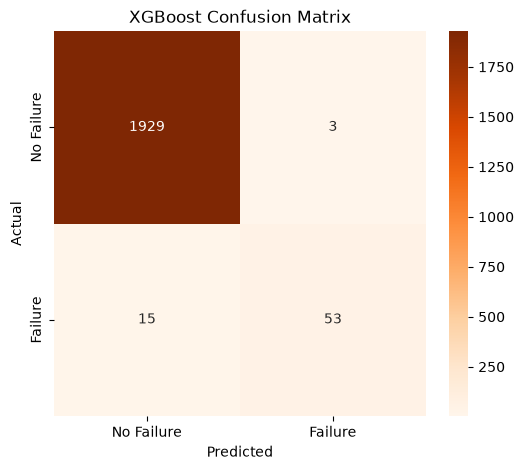

In [116]:
cm = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=[
        "No Failure",
        "Failure"
    ],
    yticklabels=[
        "No Failure",
        "Failure"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()


In [117]:
results = []


In [120]:
results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, lr_pred),
    "Precision": precision_score(
        y_test,
        lr_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        lr_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        lr_pred,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        lr_prob
    ),
    "PR-AUC": average_precision_score(
        y_test,
        lr_prob
    )
})


In [122]:
results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(
        y_test,
        rf_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        rf_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        rf_pred,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        rf_prob
    ),
    "PR-AUC": average_precision_score(
        y_test,
        rf_prob
    )
})


In [123]:
results.append({
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, xgb_pred),
    "Precision": precision_score(
        y_test,
        xgb_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        xgb_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        xgb_pred,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        xgb_prob
    ),
    "PR-AUC": average_precision_score(
        y_test,
        xgb_prob
    )
})


In [127]:
results_df = pd.DataFrame(results)

results_df



,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.9675,0.571429,0.176471,0.269663,0.925740,0.462187
1,Random Forest,0.9910,0.946429,0.779412,0.854839,0.964202,0.876897
2,XGBoost,0.9910,0.946429,0.779412,0.854839,0.978695,0.883486


In [128]:
results_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)


results_df.round(4)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.9675,0.5714,0.1765,0.2697,0.9257,0.4622
1,Random Forest,0.9910,0.9464,0.7794,0.8548,0.9642,0.8769
2,XGBoost,0.9910,0.9464,0.7794,0.8548,0.9787,0.8835


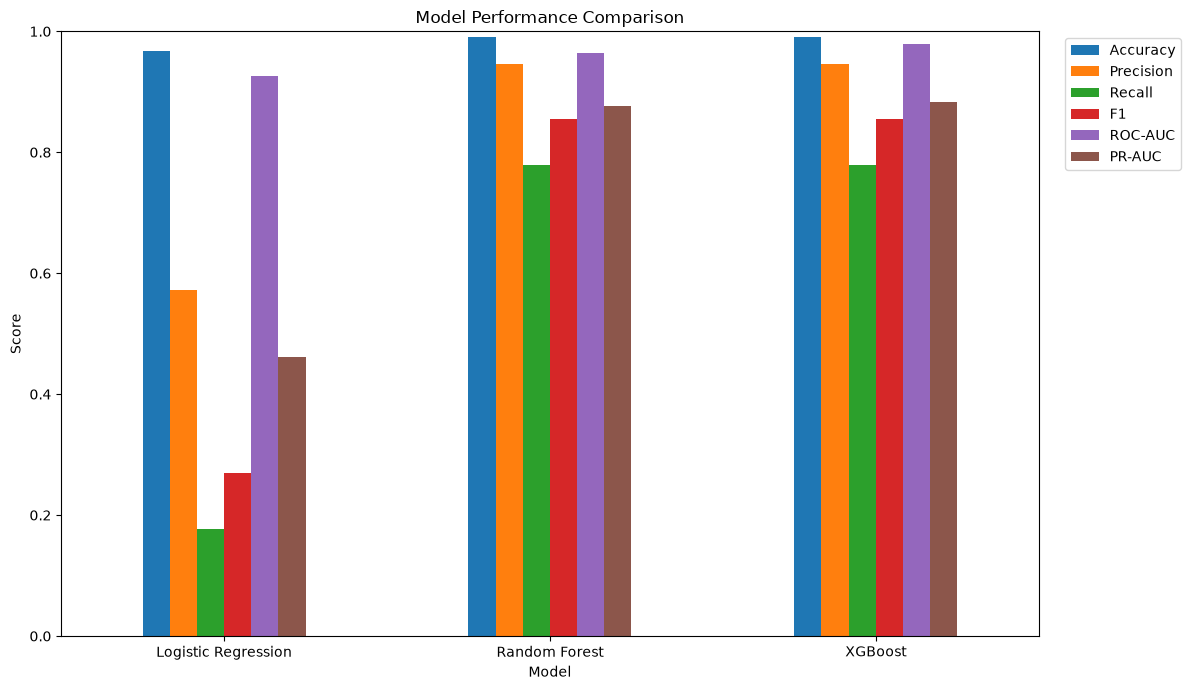

In [129]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
]

results_plot = results_df.set_index(
    "Model"
)[metrics]

results_plot.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


Class imbalance

In [88]:
y_train.value_counts()


machine_failure
0    7729
1     271
Name: count, dtype: int64

If failures are significantly less common, our model may be biased toward:
One way to address this is class weighting.

In [89]:
LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [90]:
RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

For XGBoost, we can use scale_pos_weight.



In [91]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

scale_pos_weight


np.float64(28.52029520295203)

In [92]:
XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [130]:
from sklearn.metrics import roc_curve


In [131]:
lr_fpr, lr_tpr, _ = roc_curve(
    y_test,
    lr_prob
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_prob
)

xgb_fpr, xgb_tpr, _ = roc_curve(
    y_test,
    xgb_prob
)


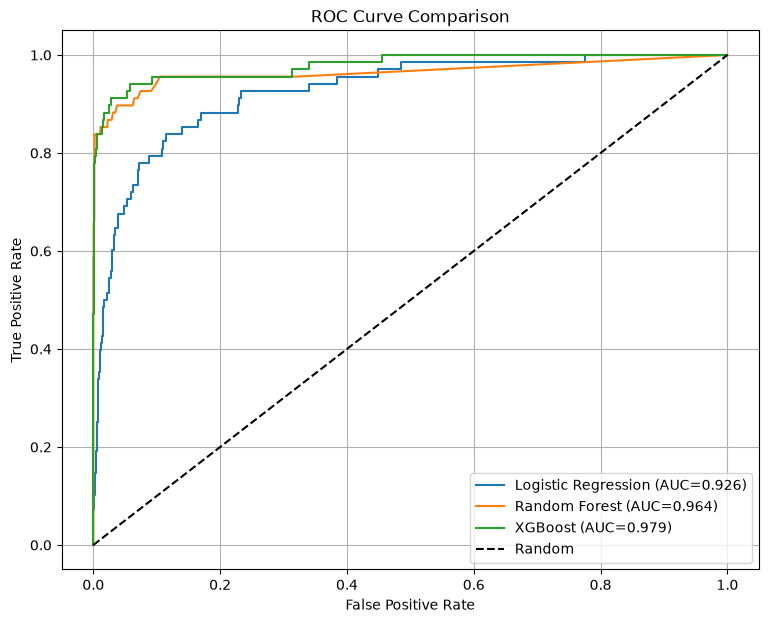

In [132]:
plt.figure(figsize=(9, 7))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC={roc_auc_score(y_test, lr_prob):.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC={roc_auc_score(y_test, rf_prob):.3f})"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGBoost (AUC={roc_auc_score(y_test, xgb_prob):.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()
plt.grid()

plt.show()


In [133]:
from sklearn.metrics import precision_recall_curve


In [134]:
lr_precision, lr_recall, _ = precision_recall_curve(
    y_test,
    lr_prob
)

rf_precision, rf_recall, _ = precision_recall_curve(
    y_test,
    rf_prob
)

xgb_precision, xgb_recall, _ = precision_recall_curve(
    y_test,
    xgb_prob
)




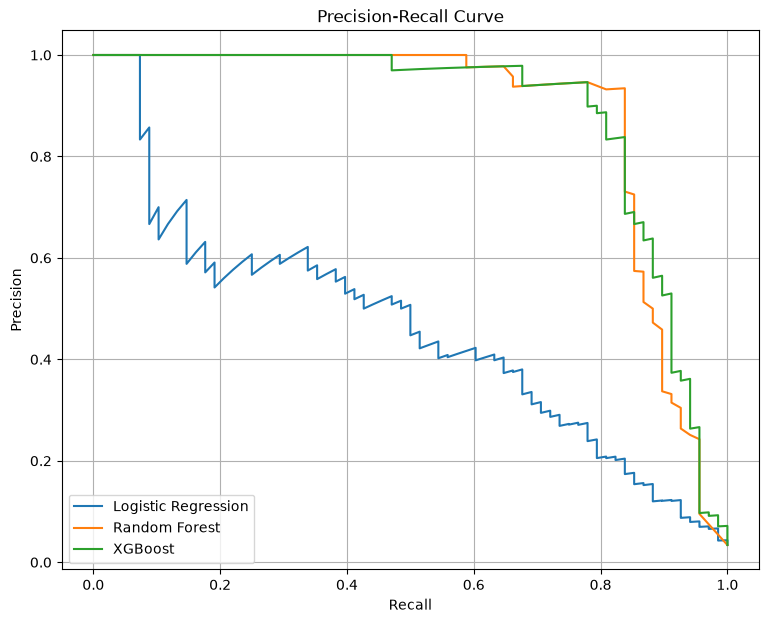

In [135]:
plt.figure(figsize=(9, 7))

plt.plot(
    lr_recall,
    lr_precision,
    label="Logistic Regression"
)

plt.plot(
    rf_recall,
    rf_precision,
    label="Random Forest"
)

plt.plot(
    xgb_recall,
    xgb_precision,
    label="XGBoost"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()
plt.grid()

plt.show()


In [136]:
from xgboost import XGBClassifier


In [137]:
xgb_balanced = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)


In [138]:
xgb_balanced.fit(
    X_train,
    y_train
)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['machine_type','air_temperature','process_temperature',...,'tool_wear', 'temperature_difference','power_proxy']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By 

In [139]:
xgb_balanced_prob = (
    xgb_balanced
    .predict_proba(X_test)[:, 1]
)


In [140]:
xgb_balanced_pred = (
    xgb_balanced_prob >= 0.5
).astype(int)


In [141]:
evaluate_model(
    "Balanced XGBoost",
    y_test,
    xgb_balanced_pred,
    xgb_balanced_prob
)



Balanced XGBoost
----------------------------------------
Accuracy : 0.9860
Precision: 0.7857
Recall   : 0.8088
F1 Score : 0.7971
ROC-AUC  : 0.9804


Hyperparameter tuning

In [142]:
from sklearn.model_selection import RandomizedSearchCV


In [143]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "classifier",
            XGBClassifier(
                scale_pos_weight=scale_pos_weight,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)


In [144]:
param_grid = {
    "classifier__n_estimators": [
        100,
        200,
        300,
        500
    ],

    "classifier__max_depth": [
        3,
        4,
        5,
        6,
        8
    ],

    "classifier__learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1
    ],

    "classifier__subsample": [
        0.7,
        0.8,
        1.0
    ],

    "classifier__colsample_bytree": [
        0.7,
        0.8,
        1.0
    ]
}


Run RandomizedSearchCV

In [145]:
search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


In [146]:
search.fit(
    X_train,
    y_train
)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': [0.7, 0.8, ...], 'classifier__learning_rate': [0.01, 0.03, ...], 'classifier__max_depth': [3, 4, ...], 'classifier__n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best est

In [147]:
print(search.best_params_)


{'classifier__subsample': 0.7, 'classifier__n_estimators': 500, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 0.8}


In [148]:
best_model = search.best_estimator_


In [149]:
best_prob = (
    best_model
    .predict_proba(X_test)[:, 1]
)


In [150]:
best_pred = (
    best_prob >= 0.5
).astype(int)


In [151]:
evaluate_model(
    "Tuned XGBoost",
    y_test,
    best_pred,
    best_prob
)



Tuned XGBoost
----------------------------------------
Accuracy : 0.9865
Precision: 0.7971
Recall   : 0.8088
F1 Score : 0.8029
ROC-AUC  : 0.9759


In [152]:
thresholds_to_test = np.arange(
    0.10,
    0.91,
    0.05
)


In [153]:
threshold_results = []

for threshold in thresholds_to_test:

    predictions = (
        best_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,

        "precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "f1": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })


In [154]:
threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df


,threshold,precision,recall,f1
0,0.10,0.644444,0.852941,0.734177
1,0.15,0.707317,0.852941,0.773333
2,0.20,0.712500,0.838235,0.770270
3,0.25,0.721519,0.838235,0.775510
4,0.30,0.750000,0.838235,0.791667
5,0.35,0.760000,0.838235,0.797203
6,0.40,0.770270,0.838235,0.802817
7,0.45,0.777778,0.823529,0.800000
8,0.50,0.797101,0.808824,0.802920
9,0.55,0.820896,0.808824,0.814815


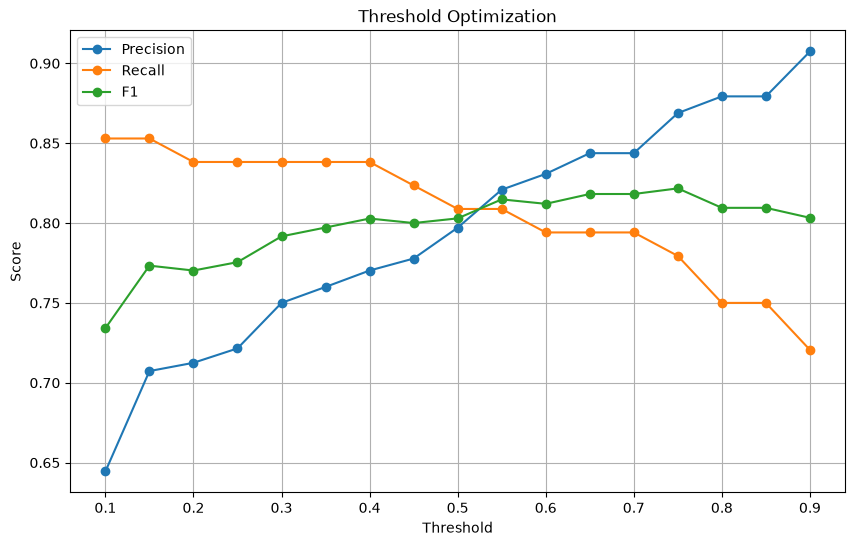

In [155]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    marker="o",
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")

plt.legend()
plt.grid()

plt.show()


In [156]:
best_threshold_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

best_threshold_row


threshold    0.750000
precision    0.868852
recall       0.779412
f1           0.821705
Name: 13, dtype: float64

In [157]:
optimal_threshold = (
    best_threshold_row["threshold"]
)

print(
    f"Optimal threshold: "
    f"{optimal_threshold:.2f}"
)


Optimal threshold: 0.75


In [158]:
final_pred = (
    best_prob >= optimal_threshold
).astype(int)


In [159]:
print(
    classification_report(
        y_test,
        final_pred,
        target_names=[
            "No Failure",
            "Failure"
        ]
    )
)


              precision    recall  f1-score   support

  No Failure       0.99      1.00      0.99      1932
     Failure       0.87      0.78      0.82        68

    accuracy                           0.99      2000
   macro avg       0.93      0.89      0.91      2000
weighted avg       0.99      0.99      0.99      2000



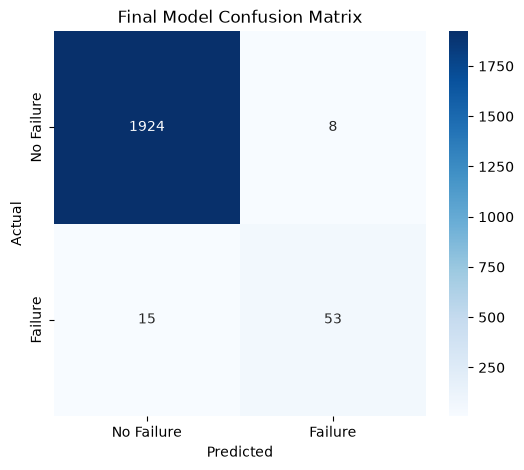

In [160]:
cm = confusion_matrix(
    y_test,
    final_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Failure",
        "Failure"
    ],
    yticklabels=[
        "No Failure",
        "Failure"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Model Confusion Matrix")

plt.show()


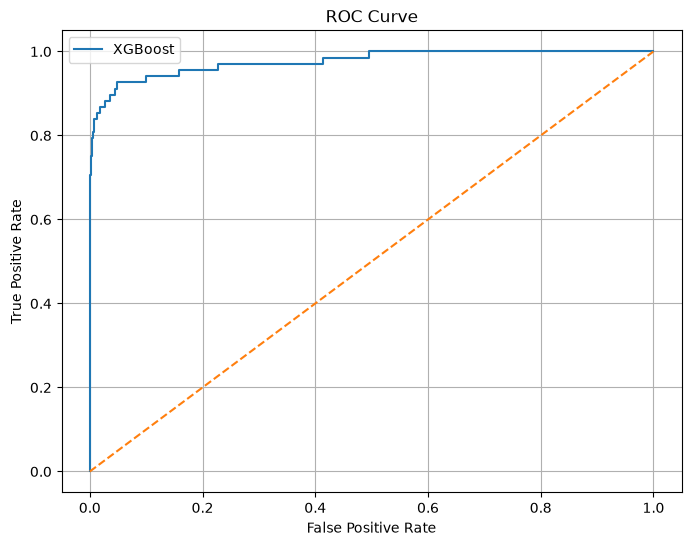

In [161]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(
    y_test,
    best_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label="XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()
plt.grid()

plt.show()


In [162]:
import joblib
import os

os.makedirs(
    "../models",
    exist_ok=True
)


In [171]:
joblib.dump(
    best_model,
    "../models/predictive_maintenance_model.pkl"
)

joblib.dump(
    best_model,
    "../models/predictive_maintenance_model.joblib"
)



['../models/predictive_maintenance_model.joblib']

In [172]:
joblib.dump(
    optimal_threshold,
    "../models/threshold.pkl"
)

joblib.dump(
    optimal_threshold,
    "../models/threshold.joblib"
)

['../models/threshold.joblib']

In [165]:
loaded_model = joblib.load(
    "../models/predictive_maintenance_model.pkl"
)


In [166]:
loaded_threshold = joblib.load(
    "../models/threshold.pkl"
)


In [167]:
test_probability = (
    loaded_model
    .predict_proba(X_test.iloc[:5])[:, 1]
)

test_probability


array([2.2871280e-02, 1.0259101e-06, 7.8730816e-03, 2.0849807e-04,
       1.3568780e-03], dtype=float32)

In [168]:
test_prediction = (
    test_probability >= loaded_threshold
).astype(int)

test_prediction


array([0, 0, 0, 0, 0])

In [177]:
! pip install fastapi uvicorn pandas numpy scikit-learn joblib streamlit plotly shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 3.1 MB/s  0:00:12m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 1.8 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]4/5 [shap]]te]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [175]:
model = joblib.load("/Users/tushar/Documents/deve/predictive-maintenance/ml/models/predictive_maintenance_model.joblib")

input_data = pd.DataFrame([
        {
    "machine_type": "M",
    "air_temperature": 300.1,
    "process_temperature": 310.2,
    "rotational_speed": 1500,
    "torque": 42.5,
    "tool_wear": 180,
            "temperature_difference": 5,
            "power_proxy": 9
        }
    ])

probability = model.predict_proba(
        input_data
    )[0][1]


probability

np.float32(0.029002719)